<a href="https://colab.research.google.com/github/aabaniel/ZeekData24-AI-Training/blob/main/CTTHES3_Models/ML_GBT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Training Section

Support Vector Machine, Gradient Boosted Trees, and Random Forest

 1. **Split** the dataset for testing and validation into folds.
 1. **Select** a machine learning algorithm to be tested with the dataset by importing a specific machine learning algorithm in scikit-learn library.
 1. **Train** using the training folds and will be tested and evaluated using the validation folds wherein the researchers will also observe its accuracy, detection rate, recall, precision, false positive rate and take the average of it.
 1. **Evaluate** the combinations of the hyperparameters to maximize the performance of the model.          
 *If the best combination is found, then it will proceed to the next step. If not, then it will undergo hyperparameter tuning to find the best combination of the hyperparameters and will undergo training with the tuned hyperparameters.*
 1. The model will then be compared with the performance of other models to determine the best based on the given evaluation metrics.
 1. The best performing model will be then tested using the testing set that is still unseen by the model.

**Input** -===- Preprocessed Dataset

**Output** -==- Model & Scaler Output

In [4]:
#%load_ext cuml.accel


In [5]:
#%pip install pandas numpy matplotlib scikit-learn imbalanced-learn

In [6]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.colors import LogNorm
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, confusion_matrix

from sklearn.preprocessing import StandardScaler


In [7]:
from sklearn.metrics import make_scorer, confusion_matrix

def multiclass_weighted_fpr(y_true, y_pred):
    """Calculates the weighted False Positive Rate for multiclass classification."""
    cm = confusion_matrix(y_true, y_pred)

    # FP: Column sum - TP (diagonal)
    fp = cm.sum(axis=0) - np.diag(cm)
    # FN: Row sum - TP (diagonal)
    fn = cm.sum(axis=1) - np.diag(cm)
    # TP: Diagonal
    tp = np.diag(cm)
    # TN: Total - (FP + FN + TP)
    tn = cm.sum() - (fp + fn + tp)

    # FPR = FP / (FP + TN)
    fpr = fp / (fp + tn)

    # Handle potential division by zero
    fpr = np.nan_to_num(fpr)

    # Return weighted average based on class support (row sums)
    weights = cm.sum(axis=1)
    return np.average(fpr, weights=weights)

# Create the scorer object
fpr_scorer = make_scorer(multiclass_weighted_fpr)

In [ ]:

train = "../datasets/final_train.csv"
test = "../datasets/test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

df.head()



,local_resp,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown,label_tactic
0,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
1,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
2,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access
3,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access
4,0,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,1,0,Credential Access


In [9]:
df = df.drop(df.columns[0], axis=1)
test_df = test_df.drop(test_df.columns[0], axis=1)
df.head()

,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,duration_bin_3.0,...,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown,label_tactic
0,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
1,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
2,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
3,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access
4,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,Credential Access


In [10]:

X_train = df.drop(columns=["label_tactic"])
y_train = df["label_tactic"]

X_test = test_df.drop(columns=["label_tactic"])
y_test = test_df["label_tactic"]


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest Section
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [12]:
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV

gbt = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators=100,
    subsample=0.7

)
gbt.fit(X_train_scaled, y_train)

#10-fold cross-validation
scoring = {
    'accuracy': 'accuracy',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'f1_weighted': 'f1_weighted',
    'fpr_weighted': fpr_scorer
}

skf_10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = cross_validate(
    gbt,
    X_train_scaled,
    y_train,
    cv=skf_10,
    scoring=scoring,
    return_train_score=True,
    n_jobs=2
)

cv_df = pd.DataFrame({
    "fold": np.arange(1, 11),
    "train_accuracy": cv_results["train_accuracy"],
    "test_accuracy": cv_results["test_accuracy"],
    "train_precision_weighted": cv_results["train_precision_weighted"],
    "test_precision_weighted": cv_results["test_precision_weighted"],
    "train_recall_weighted": cv_results["train_recall_weighted"],
    "test_recall_weighted": cv_results["test_recall_weighted"],
    "train_f1_weighted": cv_results["train_f1_weighted"],
    "test_f1_weighted": cv_results["test_f1_weighted"],
    "fit_time_sec": cv_results["fit_time"],
    "score_time_sec": cv_results["score_time"],
    "train_fpr": cv_results["train_fpr_weighted"],  # Training FPR
    "test_fpr": cv_results["test_fpr_weighted"],    # Validation FPR
})

print("10-Fold Cross-Validation (Fold-by-Fold):")
print(cv_df.round(4).to_string(index=False))

print("\nSummary (test metrics):")
for metric in ["test_accuracy", "test_precision_weighted", "test_recall_weighted", "test_f1_weighted"]:
    vals = cv_results[metric]
    print(
        f"{metric}: mean={vals.mean():.4f}, std={vals.std():.4f}, "
        f"min={vals.min():.4f}, max={vals.max():.4f}"
    )

print("\nGeneralization gap (train - test, mean):")
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    gap = cv_results[f"train_{metric}"].mean() - cv_results[f"test_{metric}"].mean()
    print(f"{metric}: {gap:.4f}")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.9],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=2,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

10-Fold Cross-Validation (Fold-by-Fold):
 fold  train_accuracy  test_accuracy  train_precision_weighted  test_precision_weighted  train_recall_weighted  test_recall_weighted  train_f1_weighted  test_f1_weighted  fit_time_sec  score_time_sec  train_fpr  test_fpr
    1          0.9394         0.9403                    0.9342                   0.9351                 0.9394                0.9403             0.9319            0.9326      148.7021          0.3049     0.0298    0.0294
    2          0.9394         0.9400                    0.9342                   0.9345                 0.9394                0.9400             0.9320            0.9321      149.3636          0.2751     0.0298    0.0295
    3          0.9397         0.9371                    0.9345                   0.9317                 0.9397                0.9371             0.9322            0.9299      140.8958          0.2551     0.0297    0.0306
    4          0.9393         0.9403                    0.9340             

In [13]:
from sklearn.metrics import cohen_kappa_score, precision_recall_curve, auc, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize


y_pred = gbt.predict(X_test_scaled)
y_pred_proba = gbt.predict_proba(X_test_scaled)

kappa = cohen_kappa_score(y_test, y_pred)
print(f"Cohen's Kappa Score: {kappa:.4f}")

classes = sorted(np.unique(y_test))
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)

print("\nPer-Class Metrics:")
print(f"{'Class':<25} {'PR-AUC':<12} {'ROC-AUC':<12}")
print("-" * 50)

pr_auc_scores = []
roc_auc_scores = []

for i, cls in enumerate(classes):
    try:
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
        pr_auc = auc(recall, precision)
        pr_auc_scores.append(pr_auc)

        roc_auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc_scores.append(roc_auc)

        print(f"{cls:<25} {pr_auc:<12.4f} {roc_auc:<12.4f}")
    except Exception as e:
        print(f"{cls:<25} Error: {str(e)}")

print("-" * 50)
print(f"{'Macro Average':<25} {np.mean(pr_auc_scores):<12.4f} {np.mean(roc_auc_scores):<12.4f}")
print(f"{'Weighted Average':<25} {np.average(pr_auc_scores, weights=np.sum(y_test_bin, axis=0)):<12.4f} {np.average(roc_auc_scores, weights=np.sum(y_test_bin, axis=0)):<12.4f}")

print(classification_report(y_test, y_pred))
print(classification_report(y_test, y_pred))

Cohen's Kappa Score: 0.9047

Per-Class Metrics:
Class                     PR-AUC       ROC-AUC     
--------------------------------------------------
Credential Access         1.0000       1.0000      
Discovery                 0.9776       0.9930      
Reconnaissance            0.4429       0.8905      
none                      0.9912       0.9917      
--------------------------------------------------
Macro Average             0.8529       0.9688      
Weighted Average          0.9675       0.9895      
                   precision    recall  f1-score   support

Credential Access       1.00      1.00      1.00      8699
        Discovery       0.86      0.99      0.92     13430
   Reconnaissance       0.58      0.31      0.40      2037
             none       0.99      0.94      0.96     27403

         accuracy                           0.94     51569
        macro avg       0.86      0.81      0.82     51569
     weighted avg       0.94      0.94      0.94     51569

           

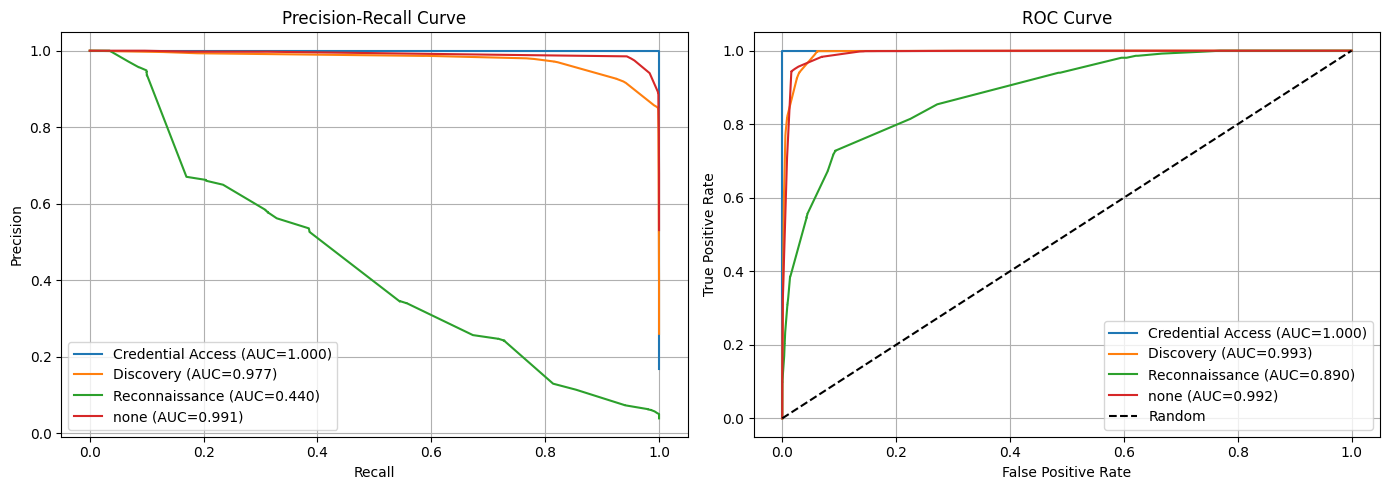

In [14]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc
from sklearn.preprocessing import label_binarize

y_pred_proba = grid_search.best_estimator_.predict_proba(X_test_scaled)
classes = sorted(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=classes)

# subplots for PR and ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot PR
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    pr_auc = auc(recall, precision)
    axes[0].plot(recall, precision, label=f'{cls} (AUC={pr_auc:.3f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend(loc='best')
axes[0].grid(True)

# plot ROC
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{cls} (AUC={roc_auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='best')
axes[1].grid(True)

plt.tight_layout()
plt.show()


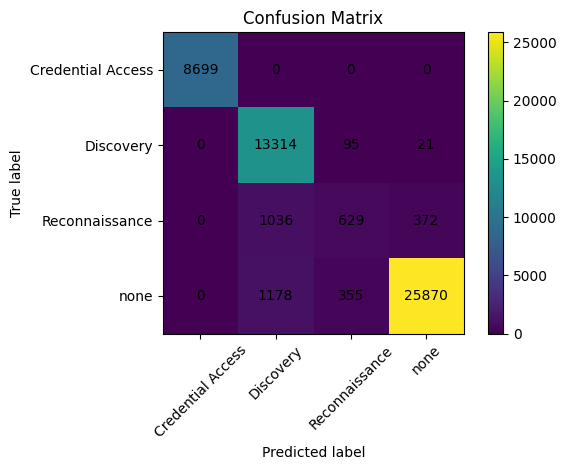

In [15]:

y_pred = grid_search.best_estimator_.predict(X_test_scaled) if "grid_search" in globals() else gbt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

class_names = sorted(np.unique(y_test))

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


In [16]:
best_model = grid_search.best_estimator_ 


y_pred = best_model.predict(X_test_scaled)
y_true = y_test

analysis_df = test_df.reset_index(drop=True).copy()

analysis_df["True Class"] = y_true.reset_index(drop=True)
analysis_df["Predicted Class"] = pd.Series(y_pred).reset_index(drop=True)

classes = sorted(y_true.unique())

for true_class in classes:
    for pred_class in classes:

        if true_class == pred_class:
            continue

        mask = (
            (analysis_df["True Class"] == true_class) &
            (analysis_df["Predicted Class"] == pred_class)
        )

        if mask.sum() == 0:
            continue

        subset = analysis_df.loc[mask].drop(
            columns=["True Class", "Predicted Class"],
            errors="ignore"
        )

        print("=" * 100)
        print(f"{true_class} ---> {pred_class}")
        print(f"Misclassified Samples: {len(subset)}")

        common_columns = {}

        for col in subset.columns:

            if pd.api.types.is_float_dtype(subset[col]):
                continue

            values = subset[col].dropna().unique()

            if len(values) == 1:
                common_columns[col] = values[0]

        if common_columns:
            print("\nCommon Columns:")
            for col, value in common_columns.items():
                print(f"{col}: {value}")
        else:
            print("\nNo columns have identical values across every sample.")

        display(subset)

Discovery ---> Reconnaissance
Misclassified Samples: 95

Common Columns:
label_tactic: Discovery
src_port_bin_1: 0
duration_bin_2.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_4.0: 0
missed_bytes_bin_6.0: 0
orig_bytes_bin_2.0: 0
orig_bytes_bin_6.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_5.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_2.0: 0
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_5.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_6.0: 0
conn_state_RSTRH: 0
conn_state_S0: 0
conn_state_SH: 0
conn_state_SHR: 0
proto_tcp: 1
proto_udp: 0
history_Arr: 0
history_D: 0
history_Dd: 0
history_F: 0
history_Fr: 0
history_Hs^ADTaFf: 0
history_Hs^ADTdttFaf: 0
history_Hs^ADfFa: 0
history_Q: 0
history_R: 0

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^hSADdR,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown
927,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1084,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1222,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1780,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
2765,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49776,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
49795,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
50017,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
50792,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


Discovery ---> none
Misclassified Samples: 21

Common Columns:
label_tactic: Discovery
src_port_bin_1: 0
dest_port_bin_3: 0
duration_bin_0.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_2.0: 0
missed_bytes_bin_4.0: 0
missed_bytes_bin_6.0: 0
orig_bytes_bin_0.0: 0
orig_bytes_bin_2.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
resp_bytes_bin_0.0: 0
resp_bytes_bin_1.0: 1
resp_bytes_bin_2.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_5.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_2.0: 0
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_5.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_6.0: 0
conn_state_OTH: 0
conn_state_REJ: 0
conn_state_RSTO: 0
conn_stat

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^hSADdR,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown
1077,Discovery,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
1306,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2087,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
4523,Discovery,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
9101,Discovery,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
12229,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
14218,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
18716,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
22654,Discovery,0,0,1,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
24092,Discovery,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0


Reconnaissance ---> Discovery
Misclassified Samples: 1036

Common Columns:
label_tactic: Reconnaissance
src_port_bin_1: 0
duration_bin_2.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_2.0: 0
missed_bytes_bin_4.0: 0
missed_bytes_bin_6.0: 0
orig_bytes_bin_2.0: 0
orig_bytes_bin_6.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_5.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_2.0: 0
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_5.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_6.0: 0
conn_state_OTH: 0
conn_state_RSTRH: 0
conn_state_SHR: 0
proto_tcp: 1
proto_udp: 0
history_A: 0
history_Arr: 0
history_D: 0
history_D

...

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^hSADdR,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown
41,Reconnaissance,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
110,Reconnaissance,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
265,Reconnaissance,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
405,Reconnaissance,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
464,Reconnaissance,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50905,Reconnaissance,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
51224,Reconnaissance,0,0,1,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
51442,Reconnaissance,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
51527,Reconnaissance,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0


none ---> Discovery
Misclassified Samples: 1178

Common Columns:
label_tactic: none
src_port_bin_1: 0
dest_port_bin_3: 0
duration_bin_2.0: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_2.0: 0
missed_bytes_bin_4.0: 0
missed_bytes_bin_6.0: 0
orig_bytes_bin_2.0: 0
orig_bytes_bin_6.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
resp_bytes_bin_2.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_5.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_2.0: 0
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_5.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_6.0: 0
conn_state_OTH: 0
conn_state_RSTO: 0
conn_state_RSTRH: 0
conn_state_SF: 0
conn_state_SHR: 0
proto_tcp: 1
proto_udp: 0
history_A: 0
history_Arr: 0
history

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^hSADdR,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown
38,none,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
39,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
113,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
195,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
223,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51449,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
51470,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
51473,none,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
51479,none,0,0,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


none ---> Reconnaissance
Misclassified Samples: 355

Common Columns:
label_tactic: none
src_port_bin_1: 0
dest_port_bin_1: 1
dest_port_bin_2: 0
dest_port_bin_3: 0
duration_bin_2.0: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_2.0: 0
missed_bytes_bin_4.0: 0
missed_bytes_bin_6.0: 0
orig_bytes_bin_2.0: 0
orig_bytes_bin_6.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
resp_bytes_bin_2.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_5.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_2.0: 0
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_5.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_6.0: 0
conn_state_RSTO: 0
conn_state_RSTRH: 0
conn_state

,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,duration_bin_2.0,...,history_^hSADdR,history_^hSR,service_dce_rpc,service_dhcp,service_dns,service_ftp,service_http,service_ntp,service_ssl,service_unknown
77,none,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
148,none,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
165,none,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
246,none,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
441,none,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50593,none,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
50895,none,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
51043,none,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
51199,none,0,0,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
